In [2]:
!pip install kagglehub nltk -q

import kagglehub
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
# Download dataset from KaggleHub
path = kagglehub.dataset_download("kazanova/sentiment140")

df = pd.read_csv(f"{path}/training.1600000.processed.noemoticon.csv",
                 encoding="latin-1", header=None,
                 names=["target", "id", "date", "flag", "user", "text"])

# Convert target: 0 = Negative, 4 → 1 (Positive)
df["target"] = df["target"].replace(4, 1)




Using Colab cache for faster access to the 'sentiment140' dataset.


In [16]:
df = df.sample(10000, random_state=42).reset_index(drop=True)
print(f"✅ Working with {len(df)} tweets")
nltk.download('punkt_tab')
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = word_tokenize(text)
    # Keep only adjectives, verbs, adverbs
    words = [lemmatizer.lemmatize(w) for w, tag in pos_tag(words)
             if w not in stop_words and tag.startswith(('J','V','R'))]
    return " ".join(words)

# Apply cleaning
df["clean_text"] = df["text"].apply(clean_text)
print("Tweets cleaned successfully!")


✅ Working with 10000 tweets


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Tweets cleaned successfully!


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["target"], test_size=0.2, random_state=42
)


In [7]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))  # unigrams + bigrams
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [8]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)


In [9]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)


In [10]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_nb = accuracy_score(y_test, y_pred_nb)

print("\n=== MODEL PERFORMANCE ===")
print(f"Logistic Regression Accuracy: {acc_lr*100:.2f}%")
print(f"Naive Bayes Accuracy: {acc_nb*100:.2f}%")

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=["Negative", "Positive"]))

print("\n--- Naive Bayes Classification Report ---")
print(classification_report(y_test, y_pred_nb, target_names=["Negative", "Positive"]))



=== MODEL PERFORMANCE ===
Logistic Regression Accuracy: 69.40%
Naive Bayes Accuracy: 67.00%

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

    Negative       0.71      0.64      0.67       980
    Positive       0.68      0.74      0.71      1020

    accuracy                           0.69      2000
   macro avg       0.70      0.69      0.69      2000
weighted avg       0.69      0.69      0.69      2000


--- Naive Bayes Classification Report ---
              precision    recall  f1-score   support

    Negative       0.65      0.73      0.68       980
    Positive       0.70      0.62      0.66      1020

    accuracy                           0.67      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.67      0.67      0.67      2000



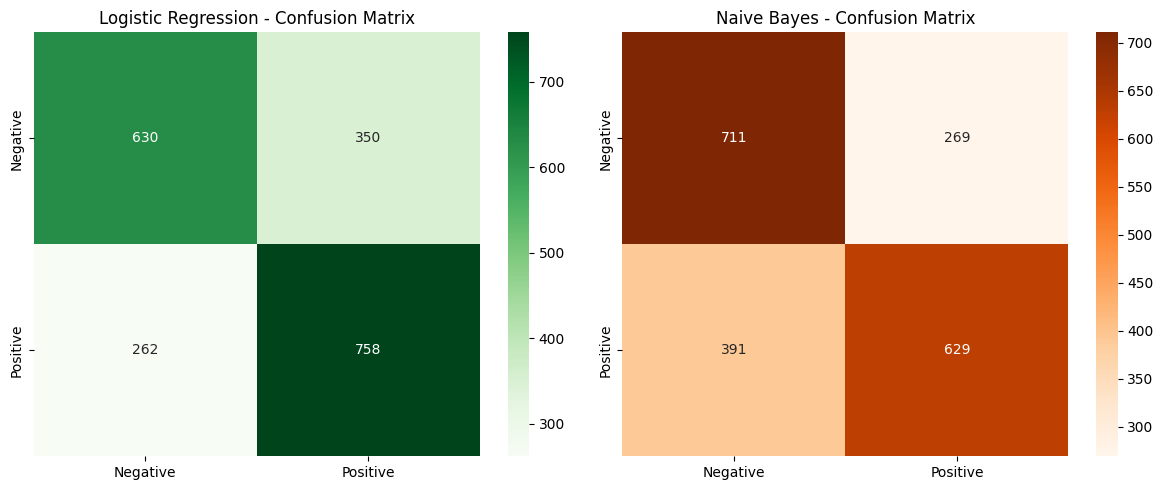

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')

# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[1])
axes[1].set_title('Naive Bayes - Confusion Matrix')

plt.tight_layout()
plt.show()


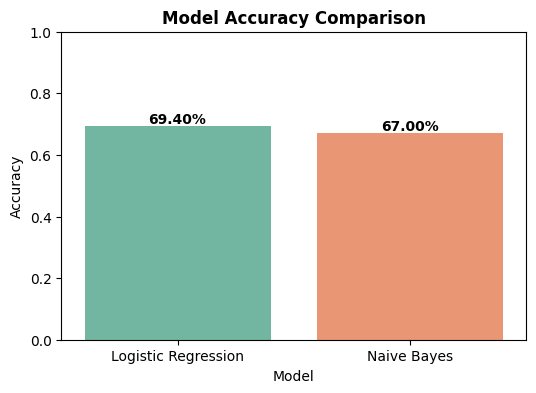

In [12]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [acc_lr, acc_nb]
})

plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="Accuracy", data=results, palette="Set2")
plt.title("Model Accuracy Comparison", fontweight="bold")
plt.ylim(0,1)
for i, val in enumerate(results["Accuracy"]):
    plt.text(i, val+0.01, f"{val*100:.2f}%", ha="center", fontweight="bold")
plt.show()


In [19]:
def predict_sentiment(text, model, model_name):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = model.predict(vec)[0]
    sentiment = "POSITIVE " if pred == 1 else "NEGATIVE "
    print(f"\n[{model_name}]")
    print(f"Tweet: {text}")
    print(f"Predicted Sentiment: {sentiment}")

sample_tweets = [
    "I absolutely love this phone!",
    "This product is terrible and a waste of money."]


print("\n=== SAMPLE PREDICTIONS ===")
for t in sample_tweets:
    predict_sentiment(t, lr, "Logistic Regression")
    predict_sentiment(t, nb, "Naive Bayes")

print("\nPROJECT COMPLETED SUCCESSFULLY!")



=== SAMPLE PREDICTIONS ===

[Logistic Regression]
Tweet: I absolutely love this phone!
Predicted Sentiment: POSITIVE 

[Naive Bayes]
Tweet: I absolutely love this phone!
Predicted Sentiment: POSITIVE 

[Logistic Regression]
Tweet: This product is terrible and a waste of money.
Predicted Sentiment: NEGATIVE 

[Naive Bayes]
Tweet: This product is terrible and a waste of money.
Predicted Sentiment: NEGATIVE 

PROJECT COMPLETED SUCCESSFULLY!
